### Implementation of Linear Regression to Predict Housing Price Using Boston dataset

A real-estate company wants to build homes at different locations in Boston. They have data for historical
prices but have not decided the actual prices yet. They want to fix such a price for the homes that are
affordable to the general public. After performing the data exploration, here apply feature engineering on the
data.

Task to be done: Make the Linear Regression Model, predicting housing prices.
Solution:
1. Check the dataframe shape and features.
2. Convert data from nd-array to data frame and adding feature names to the data.
3. Add ‘Price’ column to the dataset.
4. Get input and output data.
5. Split the dataframe into train and test data.
6. Apply Linear regression model and predict the housing price.
7. Plot the scatter graph to show the prediction result.

In [33]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [34]:
# Importing Data

import kagglehub

# Download latest version
path = kagglehub.dataset_download("jamieleech/boston-housing-dataset")

# Using your Kaggle download approach

boston = pd.read_csv(path + "/housing.csv")

#Check the dataframe shape
boston.shape 


(506, 14)

In [35]:
#Check the dataframe features.

boston.columns


Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

特征	含义
CRIM	城镇人均犯罪率
ZN	住宅用地比例
INDUS	非零售商业用地比例
CHAS	是否毗邻查尔斯河（1=是，0=否）
NOX	一氧化氮浓度
RM	每套住宅的平均房间数
AGE	1940年之前建造的自住单元比例
DIS	到波士顿中心的加权距离
RAD	辐射状公路可达性指数
TAX	每万美元的财产税率
PTRATIO	城镇师生比例
B	黑人比例
LSTAT	低收入人群比例
MEDV	目标：自住房屋房价中位数（单位：$1000）

#### Converting data from nd-array to data frame and adding feature names to the data

In [39]:
data = pd.DataFrame(boston)
data.columns = data.columns.str.strip()  # Remove leading/trailing whitespace from column names
# "  show" ---"show"
boston = boston.rename(columns={'MEDV': 'Price'})
data.head(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


#### Check the info and description on dataframe


In [40]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  Price    506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


### Getting input and output data and further splitting data to training and testing dataset:

In [41]:

# X = Input Data (The 13 features)
x = data.drop('Price', axis=1)

# y = Output Data (The target price)
y = data['Price']

# splitting data to training and testing dataset.
#from sklearn.cross_validation import train_test_split
#the submodule cross_validation is renamed and reprecated to model_selection
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size =0.2,
random_state = 0)
print("xtrain shape : ", xtrain.shape)
print("xtest shape : ", xtest.shape)
print("ytrain shape : ", ytrain.shape)
print("ytest shape : ", ytest.shape)

xtrain shape :  (404, 13)
xtest shape :  (102, 13)
ytrain shape :  (404,)
ytest shape :  (102,)


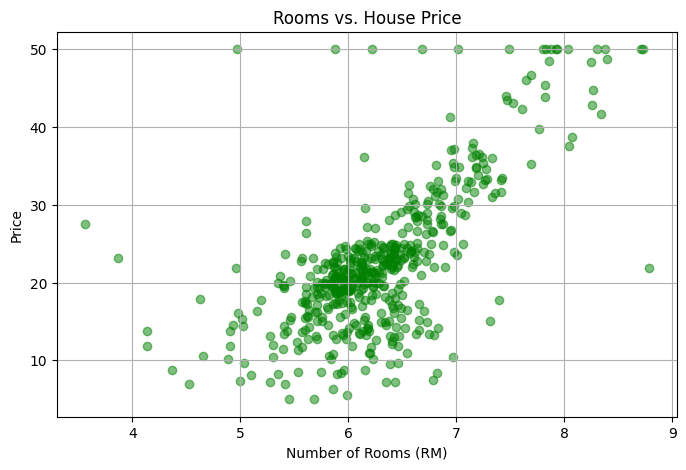

In [42]:
plt.figure(figsize=(8, 5))
plt.scatter(data['RM'], data['Price'], alpha=0.5, color='green')
plt.title('Rooms vs. House Price')
plt.xlabel('Number of Rooms (RM)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

#### Let’s now apply Linear Regression Model to the dataset and predict the prices

In [45]:
# Fitting Multi Linear regression model to training model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(xtrain, ytrain)
# predicting the test set results
y_pred = regressor.predict(xtest)



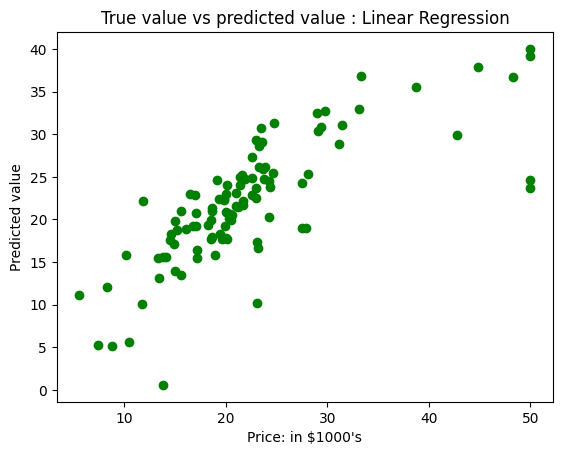

In [46]:
# Plotting Scatter graph to show the prediction results – ‘ytrue’ value vs ‘y_pred’ value:
# Plotting Scatter graph to show the prediction
# results - 'ytrue' value vs 'y_pred' value
plt.scatter(ytest, y_pred, c = 'green')
plt.xlabel("Price: in $1000's")
plt.ylabel("Predicted value")
plt.title("True value vs predicted value : Linear Regression")
plt.show()

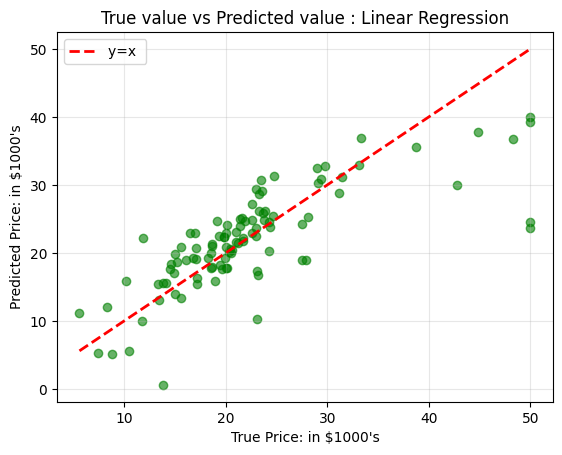

In [47]:
plt.scatter(ytest, y_pred, c='green', alpha=0.6)
plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'r--', lw=2, label='y=x ')
plt.xlabel("True Price: in $1000's")
plt.ylabel("Predicted Price: in $1000's")
plt.title("True value vs Predicted value : Linear Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

 #### And here is the result of Linear Regression - Mean Squared Error:


In [49]:
# Results of Linear Regression.
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(ytest, y_pred)
print("Mean Square Error : ", mse)

Mean Square Error :  33.44897999767649


In [57]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(ytest, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, y_pred)

print("=== Model Evaluation Results ===")
print(f"MSE  : {mse:.2f}  (thousand USD)²")
print(f"RMSE : {rmse:.2f}  thousand USD ≈ ${rmse * 1000:.0f}")
print(f"R²   : {r2:.4f}")

=== Model Evaluation Results ===
MSE  : 33.45  (thousand USD)²
RMSE : 5.78  thousand USD ≈ $5784
R²   : 0.5892


### Automatic feature selection by use Lasso 

### 1. Train Lasso Model (with automatic feature selection)

alpha is the regularization strength (equivalent to λ)

Larger alpha = stronger regularization, more weights become zero

In [66]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1, random_state = 42)
lasso.fit(xtrain, ytrain)
y_pred_lasso = lasso.predict(xtest)

### 2. View which features were selected (non-zero weights)


In [68]:


# Get feature names
feature_names = xtrain.columns.tolist()

# Get Lasso coefficients
coefficients = lasso.coef_

# Create DataFrame showing features and weights
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Selected': coefficients != 0
})

print("=== Lasso Feature Selection Results ===")
print(feature_importance.sort_values('Coefficient', ascending=False))
print(f"\nNumber of selected features: {sum(coefficients != 0)} / {len(feature_names)}")

# Identify dropped features (zero weight)
feature_names_array = np.array(feature_names)
dropped_features = feature_names_array[coefficients == 0].tolist()
if dropped_features:
    print(f"\nDropped features (weight = 0): {dropped_features}")


=== Lasso Feature Selection Results ===
    Feature  Coefficient  Selected
5        RM     3.594824      True
3      CHAS     0.842320      True
8       RAD     0.206671      True
1        ZN     0.047784      True
11        B     0.009120      True
4       NOX    -0.000000     False
9       TAX    -0.012868      True
6       AGE    -0.014483      True
2     INDUS    -0.043241      True
0      CRIM    -0.111247      True
12    LSTAT    -0.525479      True
10  PTRATIO    -0.892662      True
7       DIS    -1.111749      True

Number of selected features: 12 / 13

Dropped features (weight = 0): ['NOX']


### 3. Model Performance Evaluation


In [70]:

mse = mean_squared_error(ytest, y_pred_lasso)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, y_pred_lasso)

print("\n=== Lasso Model Evaluation Results ===")
print(f"MSE  : {mse:.2f} (thousand USD)²")
print(f"RMSE : {rmse:.2f} thousand USD ≈ ${rmse * 1000:.0f}")
print(f"R²   : {r2:.4f}")



=== Lasso Model Evaluation Results ===
MSE  : 36.07 (thousand USD)²
RMSE : 6.01 thousand USD ≈ $6006
R²   : 0.5570


### 4. Visualize Feature Importance


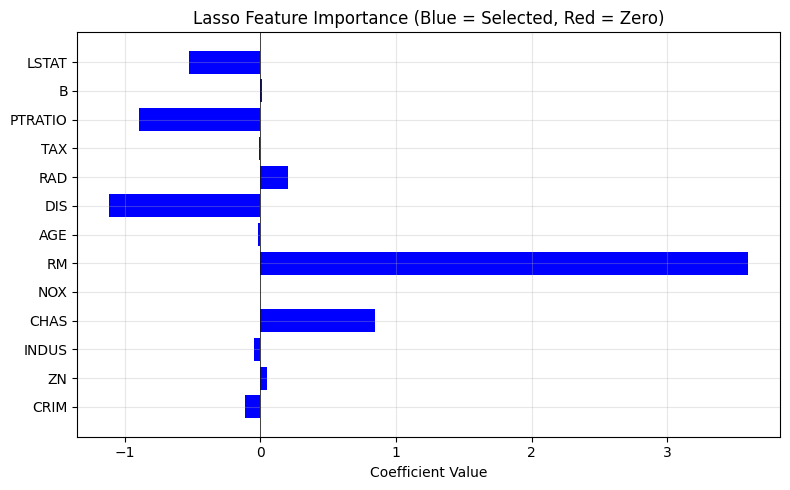

In [74]:

plt.figure(figsize=(8, 5))
colors = ['blue' if c != 0 else 'red' for c in coefficients]
plt.barh(feature_names, coefficients, color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Coefficient Value')
plt.title('Lasso Feature Importance (Blue = Selected, Red = Zero)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Compare Different Alpha Values


In [77]:

alphas = [0.01, 0.05, 0.1, 0.5, 1, 5, 10]
results = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(xtrain, ytrain)
    y_pred = lasso.predict(xtest)
    
    n_selected = sum(lasso.coef_ != 0)
    rmse = np.sqrt(mean_squared_error(ytest, y_pred))
    r2 = r2_score(ytest, y_pred)
    
    results.append({
        'alpha': alpha,
        'n_selected': n_selected,
        'rmse': rmse,
        'r2': r2
    })

    results_df = pd.DataFrame(results)
print("\n=== Comparison of Different Alpha Values ===")
print(results_df.to_string(index=False))


=== Comparison of Different Alpha Values ===
 alpha  n_selected     rmse       r2
  0.01          13 5.813169 0.584998
  0.05          12 5.985404 0.560042
  0.10          12 6.006234 0.556975
  0.50          10 6.148438 0.535748
  1.00          10 6.457561 0.487893
  5.00           5 7.090012 0.382669
 10.00           4 7.376647 0.331745


In [80]:
from sklearn.linear_model import LassoCV

# Automatically select the best alpha
lasso_cv = LassoCV(cv=5, random_state=42, alphas=np.logspace(-4, 1, 50))
lasso_cv.fit(xtrain, ytrain)

print(f"Best alpha: {lasso_cv.alpha_:.4f}")

# Retrain with the best alpha
best_lasso = Lasso(alpha=lasso_cv.alpha_, random_state=42)
best_lasso.fit(xtrain, ytrain)
y_pred_best = best_lasso.predict(xtest)

rmse_best = np.sqrt(mean_squared_error(ytest, y_pred_best))
r2_best = r2_score(ytest, y_pred_best)

print(f"Best model RMSE: {rmse_best:.2f} thousand USD ≈ ${rmse_best * 1000:.0f}")
print(f"Best model R²: {r2_best:.4f}")
print(f"Number of selected features: {sum(best_lasso.coef_ != 0)}")



Best alpha: 0.0001
Best model RMSE: 5.78 thousand USD ≈ $5784
Best model R²: 0.5892
Number of selected features: 13
